# 심층신경망을 이용한 심혈관 질환 분류 모델 실습

In [61]:
## 라이브러리 불러오기
import numpy as np 
import pandas as pd

In [62]:
## 데이터 로드
df = pd.read_csv('C:/juehyeon/aice_test/materials/datasets/CVD_cleaned.csv')

In [63]:
df.head()

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,150.0,32.66,14.54,Yes,0.0,30.0,16.0,12.0
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,165.0,77.11,28.29,No,0.0,30.0,0.0,4.0
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,163.0,88.45,33.47,No,4.0,12.0,3.0,16.0
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,180.0,93.44,28.73,No,0.0,30.0,30.0,8.0
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,191.0,88.45,24.37,Yes,0.0,8.0,4.0,0.0


In [64]:
## 결측치 확인
df.isnull().sum()

General_Health                  0
Checkup                         0
Exercise                        0
Heart_Disease                   0
Skin_Cancer                     0
Other_Cancer                    0
Depression                      0
Diabetes                        0
Arthritis                       0
Sex                             0
Age_Category                    0
Height_(cm)                     0
Weight_(kg)                     0
BMI                             0
Smoking_History                 0
Alcohol_Consumption             0
Fruit_Consumption               0
Green_Vegetables_Consumption    0
FriedPotato_Consumption         0
dtype: int64

In [65]:
## 2. 데이터 전처리
### 1) 데이터 인코딩 - 원핫 인코딩
cols = ['General_Health', 'Checkup', 'Diabetes', 'Exercise', 'Skin_Cancer', 'Other_Cancer', 'Age_Category', 'Depression', 'Arthritis', 'Sex', 'Smoking_History']
df = pd.get_dummies(data = df, columns = cols, drop_first = True)

In [66]:
df.head()

,Heart_Disease,Height_(cm),Weight_(kg),BMI,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption,General_Health_Fair,General_Health_Good,...,Age_Category_55-59,Age_Category_60-64,Age_Category_65-69,Age_Category_70-74,Age_Category_75-79,Age_Category_80+,Depression_Yes,Arthritis_Yes,Sex_Male,Smoking_History_Yes
0,No,150.0,32.66,14.54,0.0,30.0,16.0,12.0,False,False,...,False,False,False,True,False,False,False,True,False,True
1,Yes,165.0,77.11,28.29,0.0,30.0,0.0,4.0,False,False,...,False,False,False,True,False,False,False,False,False,False
2,No,163.0,88.45,33.47,4.0,12.0,3.0,16.0,False,False,...,False,True,False,False,False,False,False,False,False,False
3,Yes,180.0,93.44,28.73,0.0,30.0,30.0,8.0,False,False,...,False,False,False,False,True,False,False,False,True,False
4,No,191.0,88.45,24.37,0.0,8.0,4.0,0.0,False,True,...,False,False,False,False,False,True,False,False,True,True


In [67]:
### 2) 데이터 인코딩 - 레이블 인코딩
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['Heart_Disease'] = label_encoder.fit_transform(df['Heart_Disease'])

In [68]:
## 3. 데이터셋 분리 : 학습 데이터셋과 테스트 데이터 셋으로 분리. 
from sklearn.model_selection import train_test_split
## 입출력 데이터 분리 
X = df.drop(columns = 'Heart_Disease')
y = df['Heart_Disease']

In [69]:
## 학습, 테스트 데이터셋으로 분리 (순서 고정)
X_train, X_valid, y_train, y_valid = train_test_split(X, y,
                                                      test_size = 0.2,
                                                      stratify = y, # 균등 분리 
                                                      random_state = 42)

In [70]:
## 4. 데이터 스케일링 : 연속형 변수들의 스케일이 다를 경우 편향된 예측이 이루어질 가능성이 있기 때문에, 데이터의 각 특성을 유사한 범위로 변환하는 데이터 스케일링 작업이 필요함
from sklearn.preprocessing import MinMaxScaler

In [71]:
### 1) 스케일링 대상 컬럼 정의
scaling_columns = [
    'Height_(cm)', 'Weight_(kg)', 'BMI',
    'Alcohol_Consumption', 'Fruit_Consumption',
    'Green_Vegetables_Consumption', 'FriedPotato_Consumption'
]

In [72]:
### 2) 스케일링 객체 생성
scaler = MinMaxScaler()

In [73]:
### 3) 학습 데이터에서 스케일링 대상 컬럼만 변환
X_train_scaled = X_train.copy()
X_train_scaled[scaling_columns] = scaler.fit_transform(X_train[scaling_columns])

In [74]:
X_test_scaled = X_valid.copy()
X_test_scaled[scaling_columns] = scaler.transform(X_valid[scaling_columns]) 

In [75]:
X_train_scaled[scaling_columns].head()

,Height_(cm),Weight_(kg),BMI,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
13202,0.626667,0.287649,0.202639,0.000000,0.750000,0.062500,0.03125
306538,0.426667,0.160742,0.187263,0.000000,0.133333,0.000000,0.00000
139254,0.526667,0.270713,0.248422,0.133333,0.066667,0.093750,0.12500
146926,0.480000,0.228410,0.236259,0.033333,0.033333,0.031250,0.09375
246604,0.646667,0.439922,0.326104,0.000000,0.000000,0.117188,0.15625


In [76]:
X_test_scaled[scaling_columns].head()

,Height_(cm),Weight_(kg),BMI,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
36889,0.526667,0.143806,0.113712,1.000000,0.10,0.031250,0.234375
147153,0.480000,0.115045,0.104303,0.666667,0.75,0.093750,0.000000
112951,0.526667,0.241952,0.217900,0.000000,1.00,0.703125,0.062500
97128,0.493333,0.170888,0.159954,0.666667,0.00,0.023438,0.000000
162331,0.613333,0.177640,0.111073,0.033333,0.75,0.093750,0.031250


### 데이터를 분할하기 전에 스케일링 진행하지 않는 이유 : 
스케일링은 전체 데이터의 통계치를 사용하여 데이터를 정규화, 표준화함. 따라서 train/test를 나눈 뒤에 train 기준으로만 계산해야 test 정보가 train에 안 섞여서(데이터 누수 없이) 공정한 평가가 됨 
- 데이터 누수 : test 데이터의 통계적 흔적이 train 데이터에 스며든 상태

In [77]:
## 5. 심층신경망 모델 생성
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.models import Sequential
### 1) 시드 고정
np.random.seed(42) 
tf.random.set_seed(42)
### 2) 모델 생성
model = Sequential([
    Input(shape = (X_train.shape[1], )), 
    Dense(64, activation = 'relu'),
    Dense(32, activation = 'relu'), 
    Dense(16, activation = 'relu'),
    Dropout(0.2),
    Dense(8, activation = 'relu'),
    Dropout(0.2),
    Dense(4, activation = 'relu'), 
    Dropout(0.2),
    Dense(1, activation = 'sigmoid')
])
### 3) 모델 요약 
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,217 (20.38 KB)

 Trainable params: 5,217 (20.38 KB)

 Non-trainable params: 0 (0.00 B)

In [78]:
### param 계산 공식: (입력 뉴런 * 출력 뉴런 ) + 출력 누련 수 (편향)
X_train.shape # 피처 개수가 37이므로 37 * 64 + 64 = 2,432
### Total params - 총 파라미터 개수, Trainable Params - 학습된 파라미터 개수, Non-trainable params - 학습 x인 파라미터 개수 |

(247083, 37)

In [79]:
## 6. 모델 컴파일
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

from tensorflow.keras.callbacks import EarlyStopping

### Early Stopping 콜백 정의
early_stopping = EarlyStopping(
    monitor = 'val_loss', # 검증 손실을 기준으로 모니터링
    patience = 5, # 개선되지 않는 에폭 수 (5번 연속 개선되지 않으면 학습 중단)
    restore_best_weights = True # 가장 성능 좋은 모델 가중치 복원
)

### 모델 학습
history = model.fit(
    X_train_scaled, # 학습데이터 (입력)
    y_train, # 학습데이터 (타겟)
    validation_split = 0.2, # 학습데이터의 20% 검증용으로 사용
    epochs = 50, # 최대 학습 반복 휫수
    batch_size = 32, #배치 크기
    callbacks=[early_stopping], #얼리스탑빙 콜백
    verbose = 1 # 학습 과정 상세(1) 출력
)

Epoch 1/50
6178/6178 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - accuracy: 0.9166 - loss: 0.2698 - val_accuracy: 0.9185 - val_loss: 0.2269
Epoch 2/50
6178/6178 ━━━━━━━━━━━━━━━━━━━━ 30s 5ms/step - accuracy: 0.9189 - loss: 0.2379 - val_accuracy: 0.9185 - val_loss: 0.2256
Epoch 3/50
6178/6178 ━━━━━━━━━━━━━━━━━━━━ 27s 4ms/step - accuracy: 0.9188 - loss: 0.2350 - val_accuracy: 0.9185 - val_loss: 0.2254
Epoch 4/50
6178/6178 ━━━━━━━━━━━━━━━━━━━━ 25s 4ms/step - accuracy: 0.9188 - loss: 0.2336 - val_accuracy: 0.9185 - val_loss: 0.2252
Epoch 5/50
6178/6178 ━━━━━━━━━━━━━━━━━━━━ 26s 4ms/step - accuracy: 0.9190 - loss: 0.2336 - val_accuracy: 0.9185 - val_loss: 0.2255
Epoch 6/50
6178/6178 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step - accuracy: 0.9189 - loss: 0.2332 - val_accuracy: 0.9185 - val_loss: 0.2259
Epoch 7/50
6178/6178 ━━━━━━━━━━━━━━━━━━━━ 24s 4ms/step - accuracy: 0.9190 - loss: 0.2329 - val_accuracy: 0.9185 - val_loss: 0.2237
Epoch 8/50
6178/6178 ━━━━━━━━━━━━━━━━━━━━ 24s 4ms/step - accuracy: 0.9191 - loss: 0

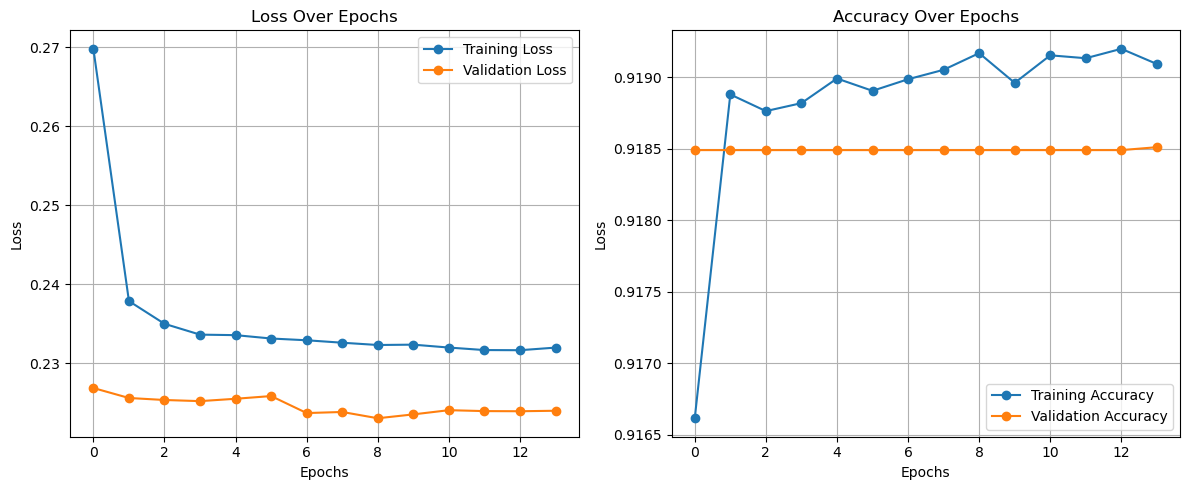

In [82]:
## 7. 모델 훈련 과정 시각화
import matplotlib.pyplot as plt
def plot_training_history(history):
    plt.figure(figsize = (12,5))
    ### 손실값(Loss)
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label = 'Training Loss', marker = 'o')
    plt.plot(history.history['val_loss'], label = 'Validation Loss', marker = 'o')
    plt.title('Loss Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    ###정확도 값
    plt.subplot(1, 2, 2)
    if 'accuracy' in history.history:
        plt.plot(history.history['accuracy'], label = 'Training Accuracy', marker = 'o')
        plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy', marker = 'o')
        plt.title('Accuracy Over Epochs')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)

    ### 그래프 출력
    plt.tight_layout()
    plt.show()

plot_training_history(history)